# FTQC 编译器：架构与逐层编译演示

本 notebook 从输入线路走到 patch 级空间调度，展示各层 IR 和图片。请使用 Python 3.11+，先在本目录运行 `python -m pip install -e ".[notebook]"`，然后在 Jupyter 中选择对应 Python 内核，执行 **Restart Kernel and Run All Cells**。

所有路径相对本 notebook 所在项目目录；图像输出到 `outputs/notebook_demo`。下面的初始化会优先使用随附的 `src`，不会读取原项目目录。


In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if not (ROOT / "src/ftqc_patch_rotation").is_dir():
    raise RuntimeError("请从包含此 notebook、pyproject.toml 和 src 的目录启动 Jupyter。")
sys.path.insert(0, str(ROOT / "src"))
from dataclasses import asdict
import json
from collections import Counter
import networkx as nx
from qiskit import QuantumCircuit, qasm2
from IPython.display import display, Image, HTML
import ftqc_patch_rotation
from ftqc_patch_rotation import (
    Processor, ProcessorConfig, preprocess, compile_processor,
    save_compilation, load_compilation, validate_schedule,
)
from ftqc_patch_rotation.hardware_visualize import draw_hardware_schedule
from ftqc_patch_rotation.visualize import draw_compiled_circuit
assert Path(ftqc_patch_rotation.__file__).resolve().is_relative_to(ROOT / "src")
OUT = ROOT / "outputs/notebook_demo"
OUT.mkdir(parents=True, exist_ok=True)
def show_json(value):
    print(json.dumps(value, ensure_ascii=False, indent=2, default=str))
print("源码：", ftqc_patch_rotation.__file__)
print("输出：", OUT)


源码： D:\work\naqc\work-files\ftqc-compiler\src\ftqc_patch_rotation\__init__.py
输出： D:\work\naqc\work-files\ftqc-compiler\outputs\notebook_demo


## 1. 项目架构

实线表示已实现；橙色虚线表示未来接入关系。内部原子移动、deformation 二次并行调度、SE、真实动态反馈和耗时优化尚未实现。
已有扩展参数包括 `optimizer`、空间调度的 `mapping` 和 `cost_fn`；后者当前用于计算结果代价，并不会自动改变规划策略。


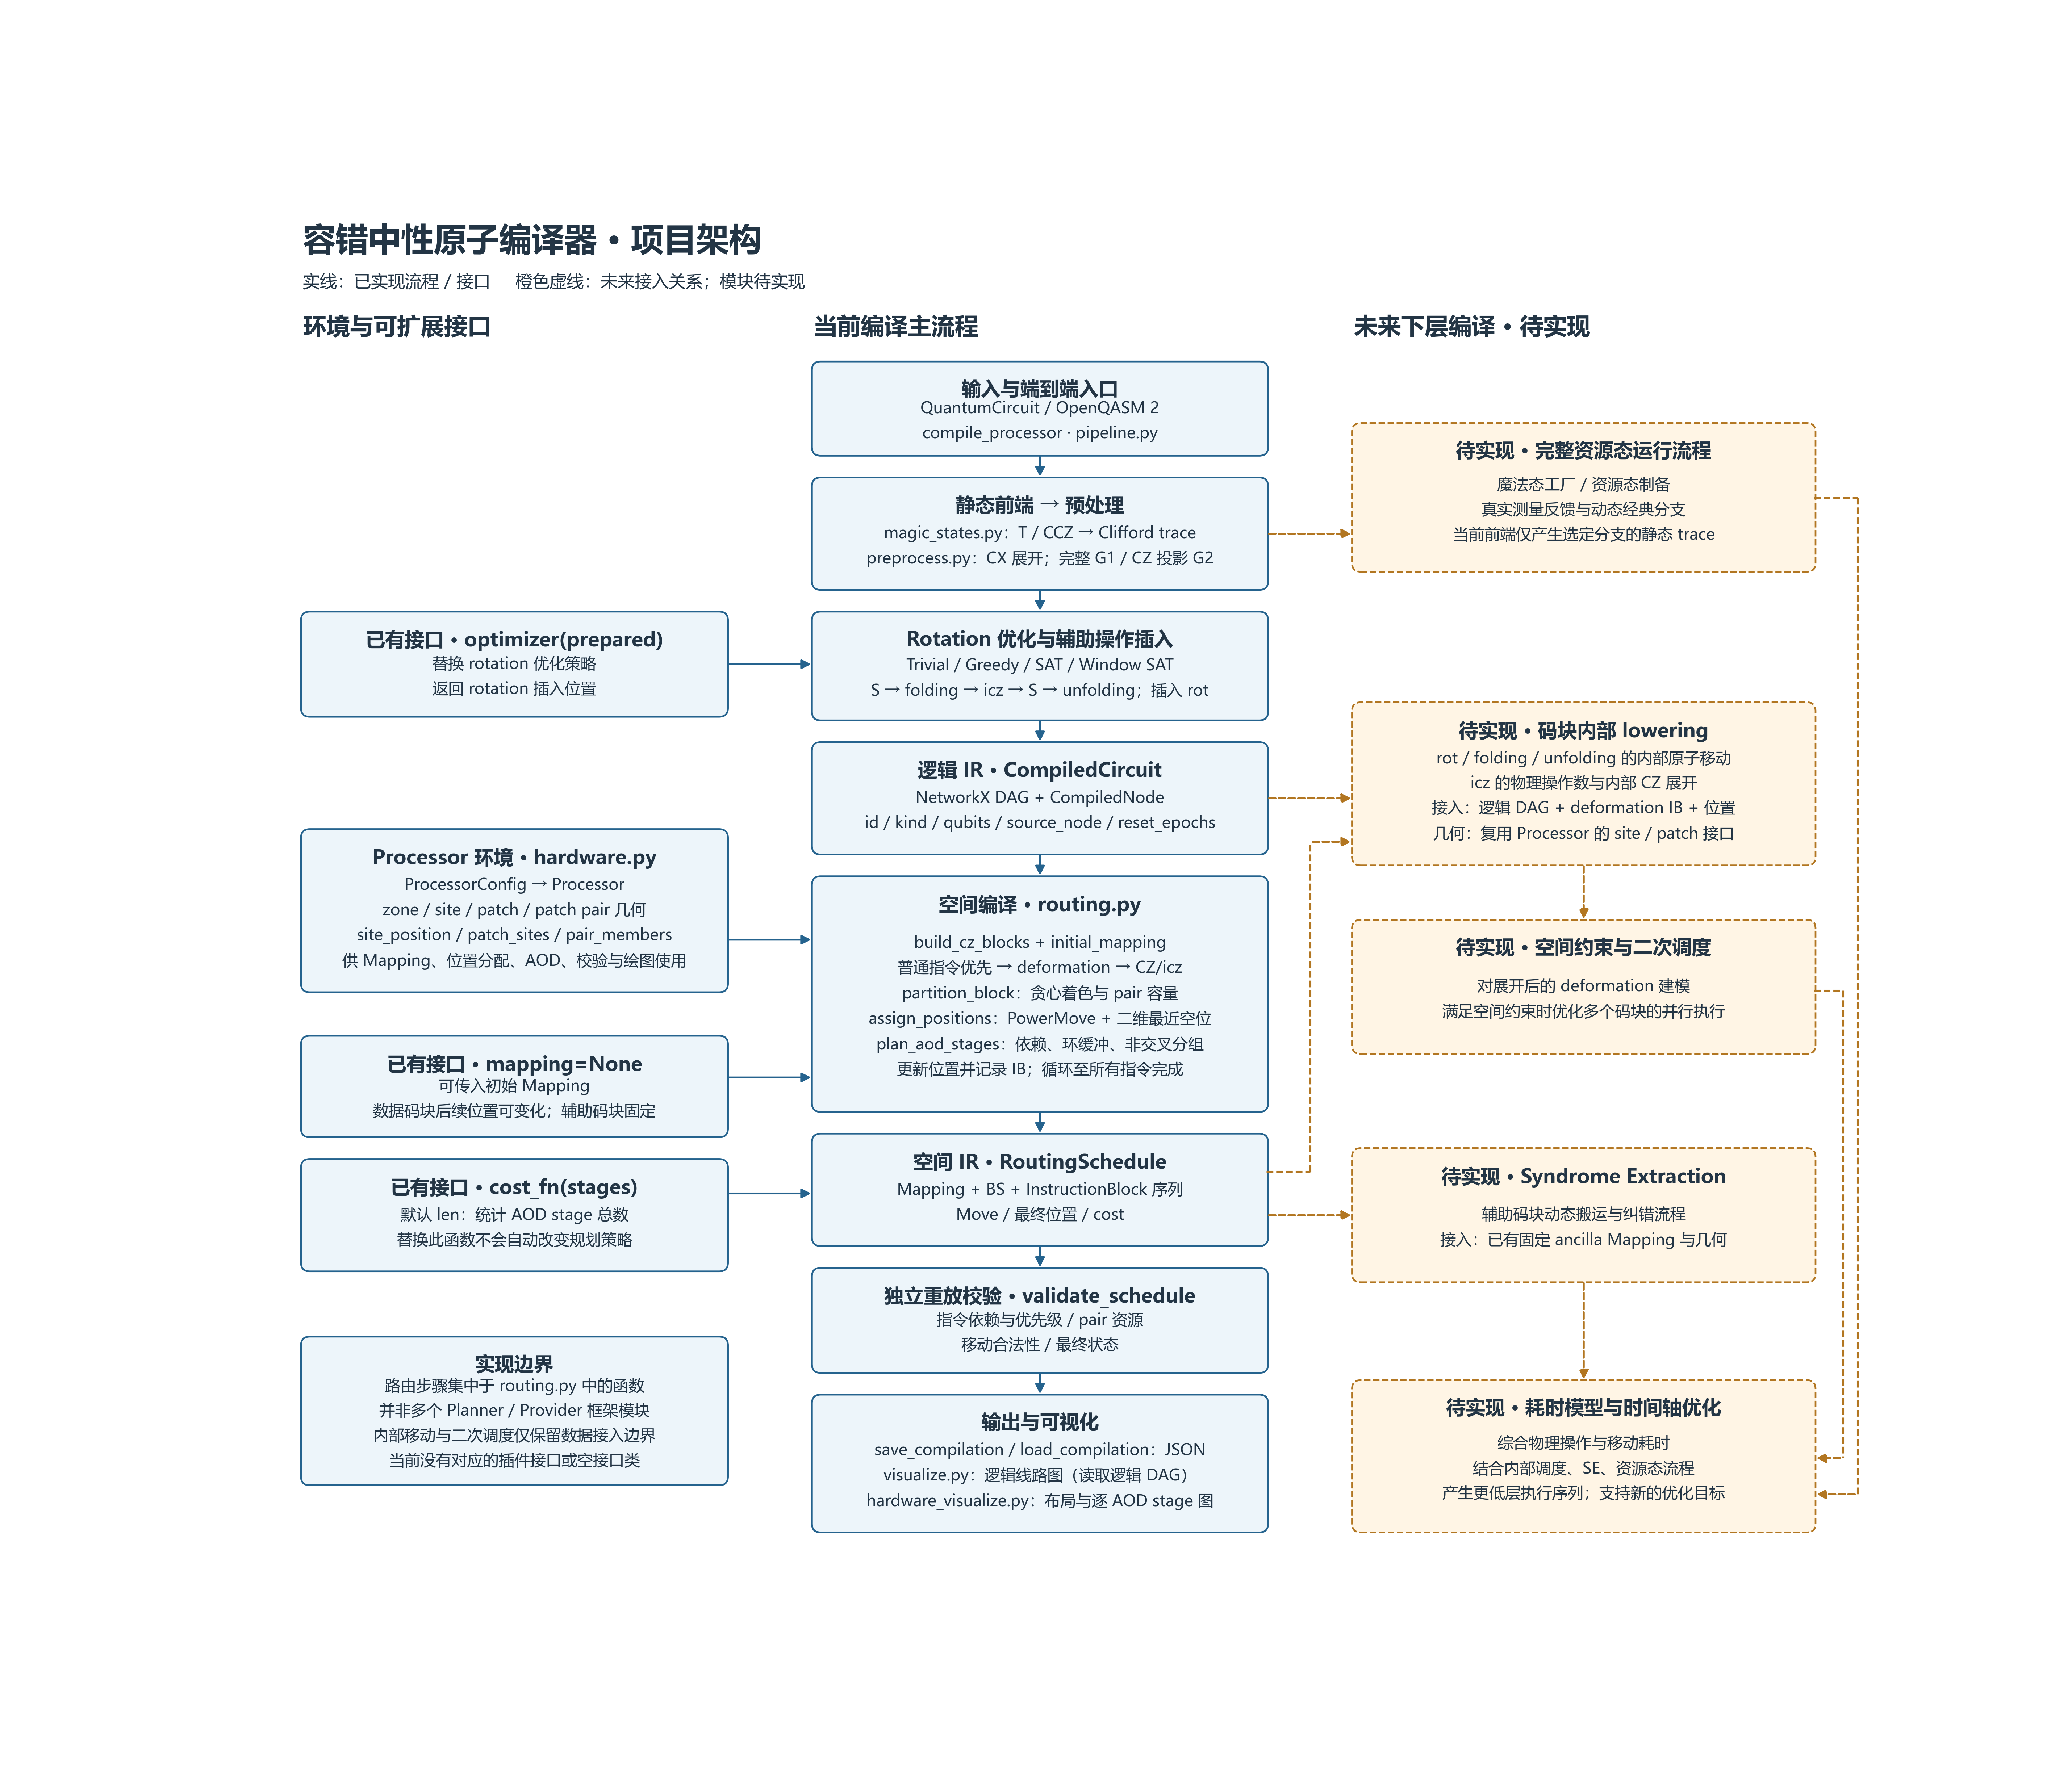

In [2]:
display(Image(filename=str(ROOT / "项目架构图.png"), width=1300))

## 2. Processor 配置

码距 d=3。storage/measurement 的 site 间距 s=5 μm；entanglement 的 site-pair 间距为 2s，pair 内偏移为 s/5；zone 间距均为 2s，按最近 site 行计算，三个 zone 左对齐。
数据码块与固定辅助码块分别占用 storage 上下区域；初始 Mapping 不约束之后返回哪个空闲 data patch。


In [3]:
config = ProcessorConfig(
    d=3, a1=4, b1=5, a2=3, b2=2,
    s=5, pair_pitch_x=10, pair_pitch_y=10, pair_offset=1,
    gap_se=10, gap_em=10, L=81, H=180,
)
processor = Processor(config)
show_json(asdict(config))
show_json(processor.to_dict())


{
  "d": 3,
  "a1": 4,
  "b1": 5,
  "a2": 3,
  "b2": 2,
  "s": 5,
  "pair_pitch_x": 10,
  "pair_pitch_y": 10,
  "pair_offset": 1,
  "gap_se": 10,
  "gap_em": 10,
  "L": 81,
  "H": 180
}
{
  "config": {
    "d": 3,
    "a1": 4,
    "b1": 5,
    "a2": 3,
    "b2": 2,
    "s": 5,
    "pair_pitch_x": 10,
    "pair_pitch_y": 10,
    "pair_offset": 1,
    "gap_se": 10,
    "gap_em": 10,
    "L": 81,
    "H": 180
  },
  "L": "81",
  "H": "180",
  "patches": [
    {
      "id": "storage:0:0",
      "zone": "storage",
      "row": 0,
      "col": 0,
      "x": "0",
      "y": "0",
      "pair": null,
      "member": null
    },
    {
      "id": "storage:0:1",
      "zone": "storage",
      "row": 0,
      "col": 1,
      "x": "15",
      "y": "0",
      "pair": null,
      "member": null
    },
    {
      "id": "storage:0:2",
      "zone": "storage",
      "row": 0,
      "col": 2,
      "x": "30",
      "y": "0",
      "pair": null,
      "member": null
    },
    {
      "id": "storage:0:3"

## 3. 输入线路与静态前端

示例包含 T、CCZ 魔法态转换，以及 S 展开、CX 展开和 reset。固定 seed=7 保证示例可重复。
魔法态转换选择一个测量分支，输出静态 Clifford trace；这不是完整的动态测量反馈实现。资源比特会使转换后比特数大于输入比特数。


In [4]:
circuit = QuantumCircuit(3)
circuit.h(0)
circuit.t(0)
circuit.ccz(0, 1, 2)
circuit.s(1)
circuit.cx(1, 2)
circuit.reset(0)
circuit.cz(0, 2)
print(circuit.draw(output="text"))
(OUT / "input.qasm").write_text(qasm2.dumps(circuit), encoding="utf-8")
compiled, schedule, metadata = compile_processor(circuit, processor, seed=7)
clifford = qasm2.loads(metadata["static_trace_qasm"])
print("\n静态 Clifford trace：")
print(clifford.draw(output="text"))
show_json(metadata["magic_state_conversion"])
(OUT / "clifford.qasm").write_text(metadata["static_trace_qasm"], encoding="utf-8")


     ┌───┐┌───┐                
q_0: ┤ H ├┤ T ├─■──|0>───────■─
     └───┘└───┘ │ ┌───┐      │ 
q_1: ───────────■─┤ S ├──■───┼─
                │ └───┘┌─┴─┐ │ 
q_2: ───────────■──────┤ X ├─■─
                       └───┘   

静态 Clifford trace：
           ┌───┐          ┌───┐                               
      q_0: ┤ H ├───────■──┤ S ├───────■───■──|0>────────────■─
           └───┘       │  ├───┤       │   │                 │ 
      q_1: ───────■────┼──┤ S ├───────┼───┼─────────────■───┼─
           ┌───┐  │    │  ├───┤       │   │ ┌───┐┌───┐┌─┴─┐ │ 
      q_2: ┤ H ├──┼────┼──┤ H ├──■────┼───■─┤ H ├┤ H ├┤ X ├─■─
           └───┘  │    │  └───┘  │  ┌─┴─┐   └┬─┬┘└───┘└───┘   
 cczreg_0: ───────┼────┼─────────┼──┤ X ├────┤M├──|0>─────────
                ┌─┴─┐  │   ┌─┐   │  └───┘    └╥┘              
 cczreg_1: ─────┤ X ├──┼───┤M├───┼───|0>──────╫───────────────
                └───┘  │   └╥┘ ┌─┴─┐     ┌─┐  ║               
 cczreg_2: ────────────┼────╫──┤ X ├─────┤M├──╫───|0>─────────


486

## 4. 预处理 IR：G1 与 G2

`PreparedCircuit.g1` 为完整门 DAG；`g2` 为 CZ 投影，供 rotation 优化器使用。二者都是 NetworkX DiGraph，节点携带 GateNode。
这里从同一静态 trace 重建预处理结果，仅用于展示，不重复进行端到端编译。
`reset_epochs` 记录各操作所属的 reset 段，防止 rotation 跨 reset 错误影响未来门。


In [5]:
prepared = preprocess(clifford)
for name, graph in (("g1", prepared.g1), ("g2", prepared.g2)):
    payload = {
        "nodes": [asdict(graph.nodes[n]["gate"]) for n in nx.topological_sort(graph)],
        "edges": list(graph.edges),
    }
    print(f"\n{name}: {len(graph)} nodes, {graph.number_of_edges()} edges")
    show_json(payload)
    (OUT / f"{name}.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")



g1: 33 nodes, 33 edges
{
  "nodes": [
    {
      "id": 0,
      "kind": "h",
      "qubits": [
        0
      ],
      "is_executable": null,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 1,
      "kind": "h",
      "qubits": [
        6
      ],
      "is_executable": null,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 7,
      "kind": "h",
      "qubits": [
        2
      ],
      "is_executable": null,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 9,
      "kind": "h",
      "qubits": [
        3
      ],
      "is_executable": null,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 12,
      "kind": "h",
      "qubits": [
        4
      ],
      "is_executable": null,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 15,
      "kind": "h",
      "qubits": [
        5
      ],
      "is_executable": null,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 2,
      "k

## 5. 插入 deformation 后的逻辑 IR 与线路图

`CompiledCircuit` 保留所有逻辑操作、依赖边、原始节点追溯和 rotation 序列。
S 展开为 **folding → icz → S → unfolding**；icz 只作用于一个逻辑比特，但空间调度时独占整个 patch pair。
rot / folding / unfolding 当前还是抽象操作，没有展开内部原子移动。图中 H/rot 可改变 orientation 颜色；folding/icz/unfolding 不改变颜色。


Rotation 插入序列： (0, 0, 0)
操作统计： {'h': 15, 'cz': 7, 'folding': 2, 'icz': 2, 's': 2, 'unfolding': 2, 'measure': 4, 'reset': 5, 'rot': 3}
{
  "nodes": [
    {
      "id": 0,
      "kind": "h",
      "qubits": [
        0
      ],
      "source_node": 0,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 1,
      "kind": "h",
      "qubits": [
        6
      ],
      "source_node": 1,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 2,
      "kind": "h",
      "qubits": [
        2
      ],
      "source_node": 7,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 3,
      "kind": "h",
      "qubits": [
        3
      ],
      "source_node": 9,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 4,
      "kind": "h",
      "qubits": [
        4
      ],
      "source_node": 12,
      "reset_epochs": [
        0
      ]
    },
    {
      "id": 5,
      "kind": "h",
      "qubits": [
        5
      ],
      "source_node": 15

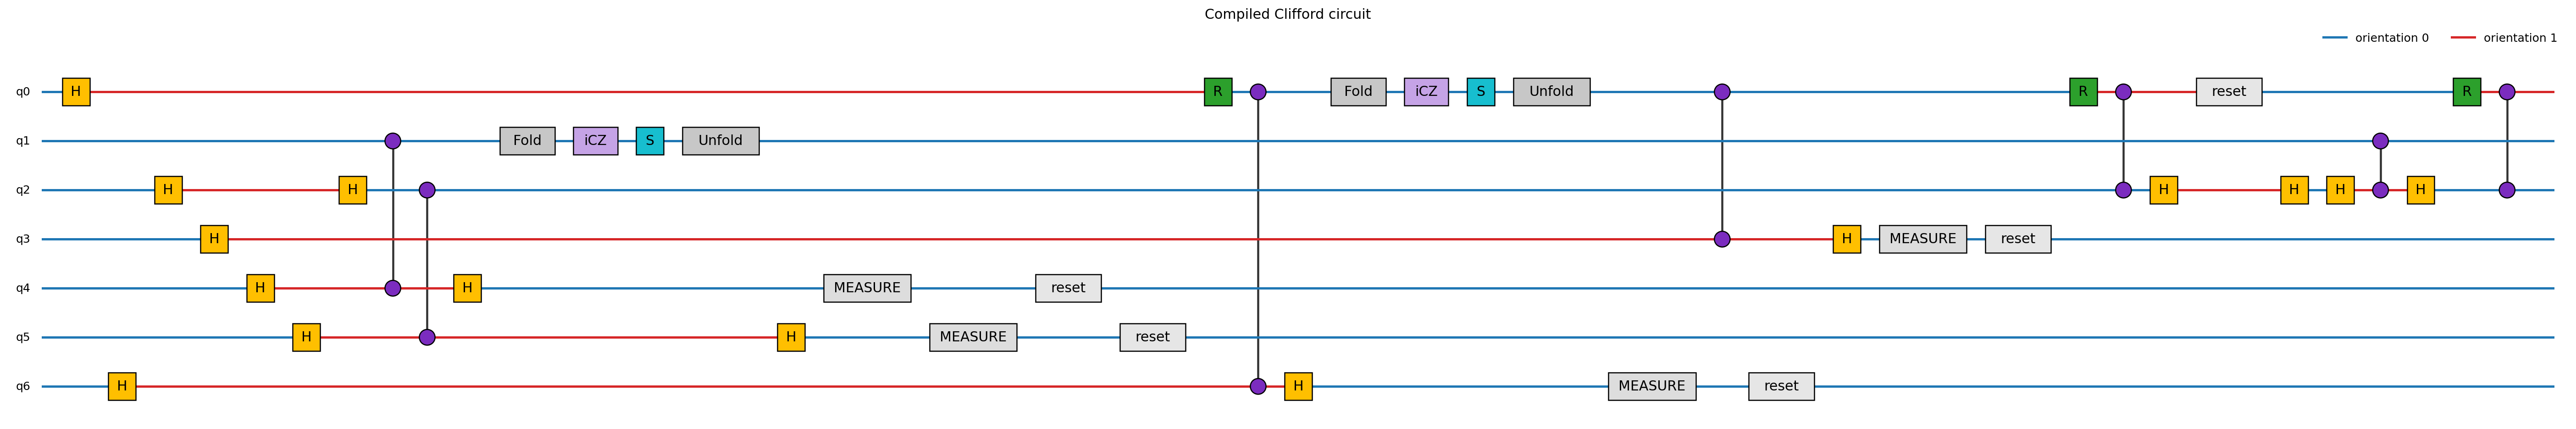

In [6]:
print("Rotation 插入序列：", compiled.rotations)
print("操作统计：", dict(Counter(op.kind for op in compiled.operations())))
show_json({"nodes": [asdict(op) for op in compiled.operations()],
           "edges": list(compiled.dag.edges)})
logical_image = draw_compiled_circuit(compiled, OUT / "logical_circuit.png")
display(Image(filename=str(logical_image)))


## 6. 初始 Mapping、CZ blocks 与空间调度 IR

Mapping 保存数据和辅助码块初始 patch；BS 保存 cz/icz 节点 ID 分组。
调度优先释放普通门，然后 deformation，最后处理 CZ/icz。BS 内采用贪心着色，位置分配后进行带移动依赖和环缓冲的 AOD 分组。
InstructionBlock 分为 ordinary、deformation、cz、aod。普通 IB 中的指令按记录顺序执行，不代表整个 IB 并行。


In [7]:
print("初始 Mapping：")
show_json(asdict(schedule.mapping))
print("CZ block sequence（展开节点含义）：")
for i, block in enumerate(schedule.cz_blocks):
    print(f"BS[{i}]")
    show_json([asdict(compiled.operation(n)) for n in block])
print("全部 InstructionBlock：")
for i, block in enumerate(schedule.blocks):
    print(f"IB[{i}] / {block.kind}")
    show_json(asdict(block))
print("最终位置：")
show_json(schedule.final_positions)
print("AOD stage 数：", schedule.stage_count, "；代价：", schedule.cost)


初始 Mapping：
{
  "initial_data_patch": {
    "0": "storage:2:0",
    "1": "storage:2:1",
    "2": "storage:2:2",
    "4": "storage:2:3",
    "5": "storage:2:4",
    "6": "storage:3:0",
    "3": "storage:3:1"
  },
  "ancilla_patch": {
    "0": "storage:0:0",
    "1": "storage:0:1",
    "2": "storage:0:2",
    "4": "storage:0:3",
    "5": "storage:0:4",
    "6": "storage:1:0",
    "3": "storage:1:1"
  }
}
CZ block sequence（展开节点含义）：
BS[0]
[
  {
    "id": 7,
    "kind": "cz",
    "qubits": [
      1,
      4
    ],
    "source_node": 13,
    "reset_epochs": [
      0,
      0
    ]
  },
  {
    "id": 8,
    "kind": "cz",
    "qubits": [
      2,
      5
    ],
    "source_node": 16,
    "reset_epochs": [
      0,
      0
    ]
  },
  {
    "id": 20,
    "kind": "cz",
    "qubits": [
      0,
      6
    ],
    "source_node": 2,
    "reset_epochs": [
      0,
      0
    ]
  }
]
BS[1]
[
  {
    "id": 11,
    "kind": "icz",
    "qubits": [
      1
    ],
    "source_node": 27,
    "reset_epoc

## 7. 保存、加载与独立重放校验

JSON 保存 processor 配置、完整逻辑 DAG、Mapping、BS、指令块、最终位置与前端元数据。
加载时重建对象并校验调度。以下断言检查往返序列化与 AOD 计数。


In [8]:
report = validate_schedule(compiled, processor, schedule)
show_json(report)
artifact = save_compilation(OUT / "compilation.json", compiled, processor, schedule, metadata)
restored_circuit, restored_processor, restored_schedule, restored_meta = load_compilation(artifact)
assert restored_schedule.to_dict() == schedule.to_dict()
assert list(restored_circuit.operations()) == list(compiled.operations())
assert set(restored_circuit.dag.edges) == set(compiled.dag.edges)
assert restored_meta == metadata
assert schedule.stage_count == sum(b.kind == "aod" for b in schedule.blocks)
print("序列化往返与调度校验通过：", artifact)


{
  "valid": true,
  "operations": 42,
  "aod_stages": 15,
  "final_orientation": [
    true,
    false,
    false,
    false,
    false,
    false,
    false
  ],
  "reset_epochs": [
    1,
    0,
    0,
    1,
    1,
    1,
    1
  ]
}
序列化往返与调度校验通过： D:\work\naqc\work-files\ftqc-compiler\outputs\notebook_demo\compilation.json


## 8. 初始布局、全部 AOD stage 与最终位置

彩色半透明矩形覆盖整个数据 patch；灰色矩形表示固定辅助 patch。
箭头连接起止 patch 中心，无填充虚线框表示目标 patch；每张 stage 图显示该 stage 开始时的位置及本轮移动。
这些是 patch 级移动图，不是码块内部原子轨迹。概览覆盖所有 stage，之后可用编号查看单张高清图。


初始布局


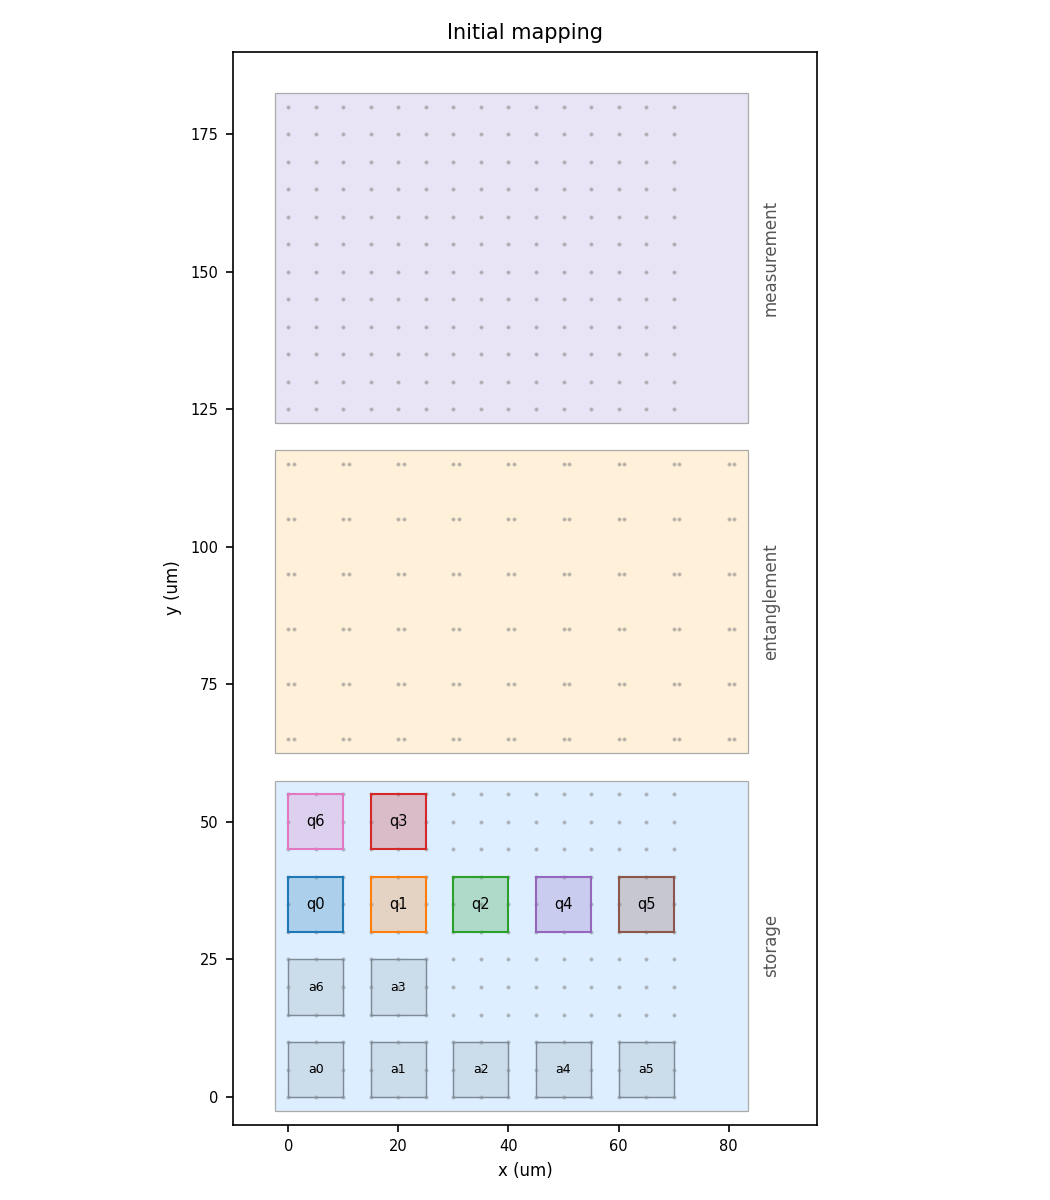

overview_01.png


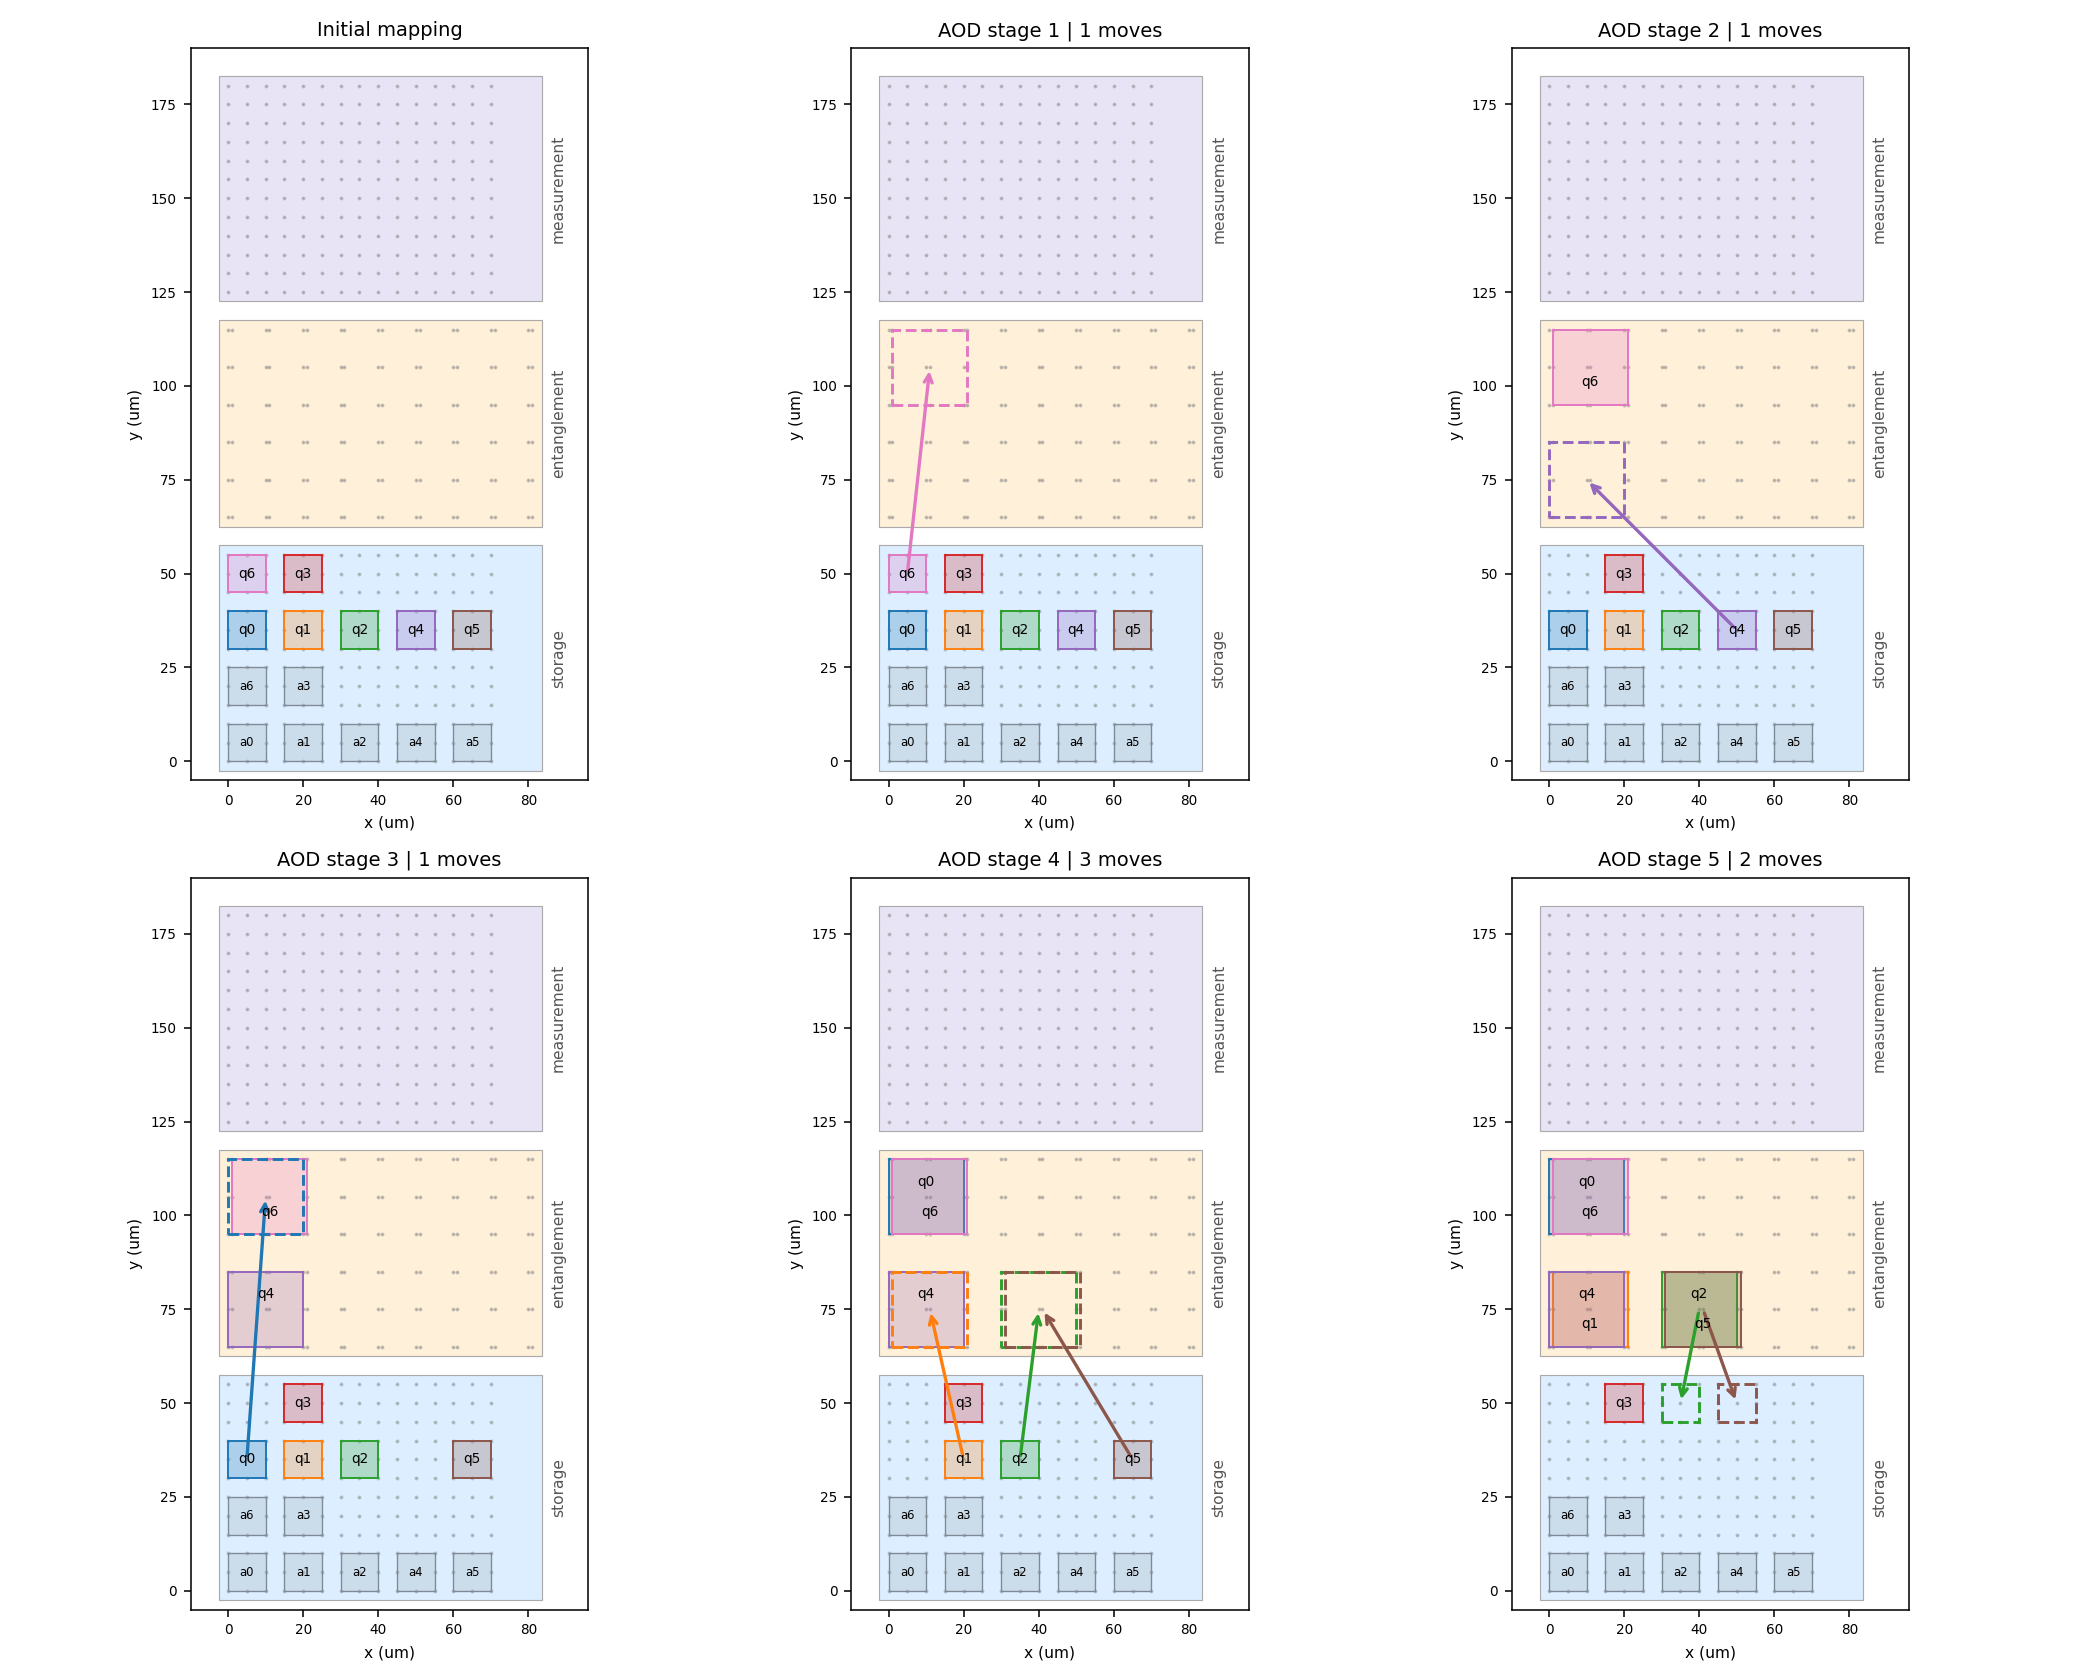

overview_02.png


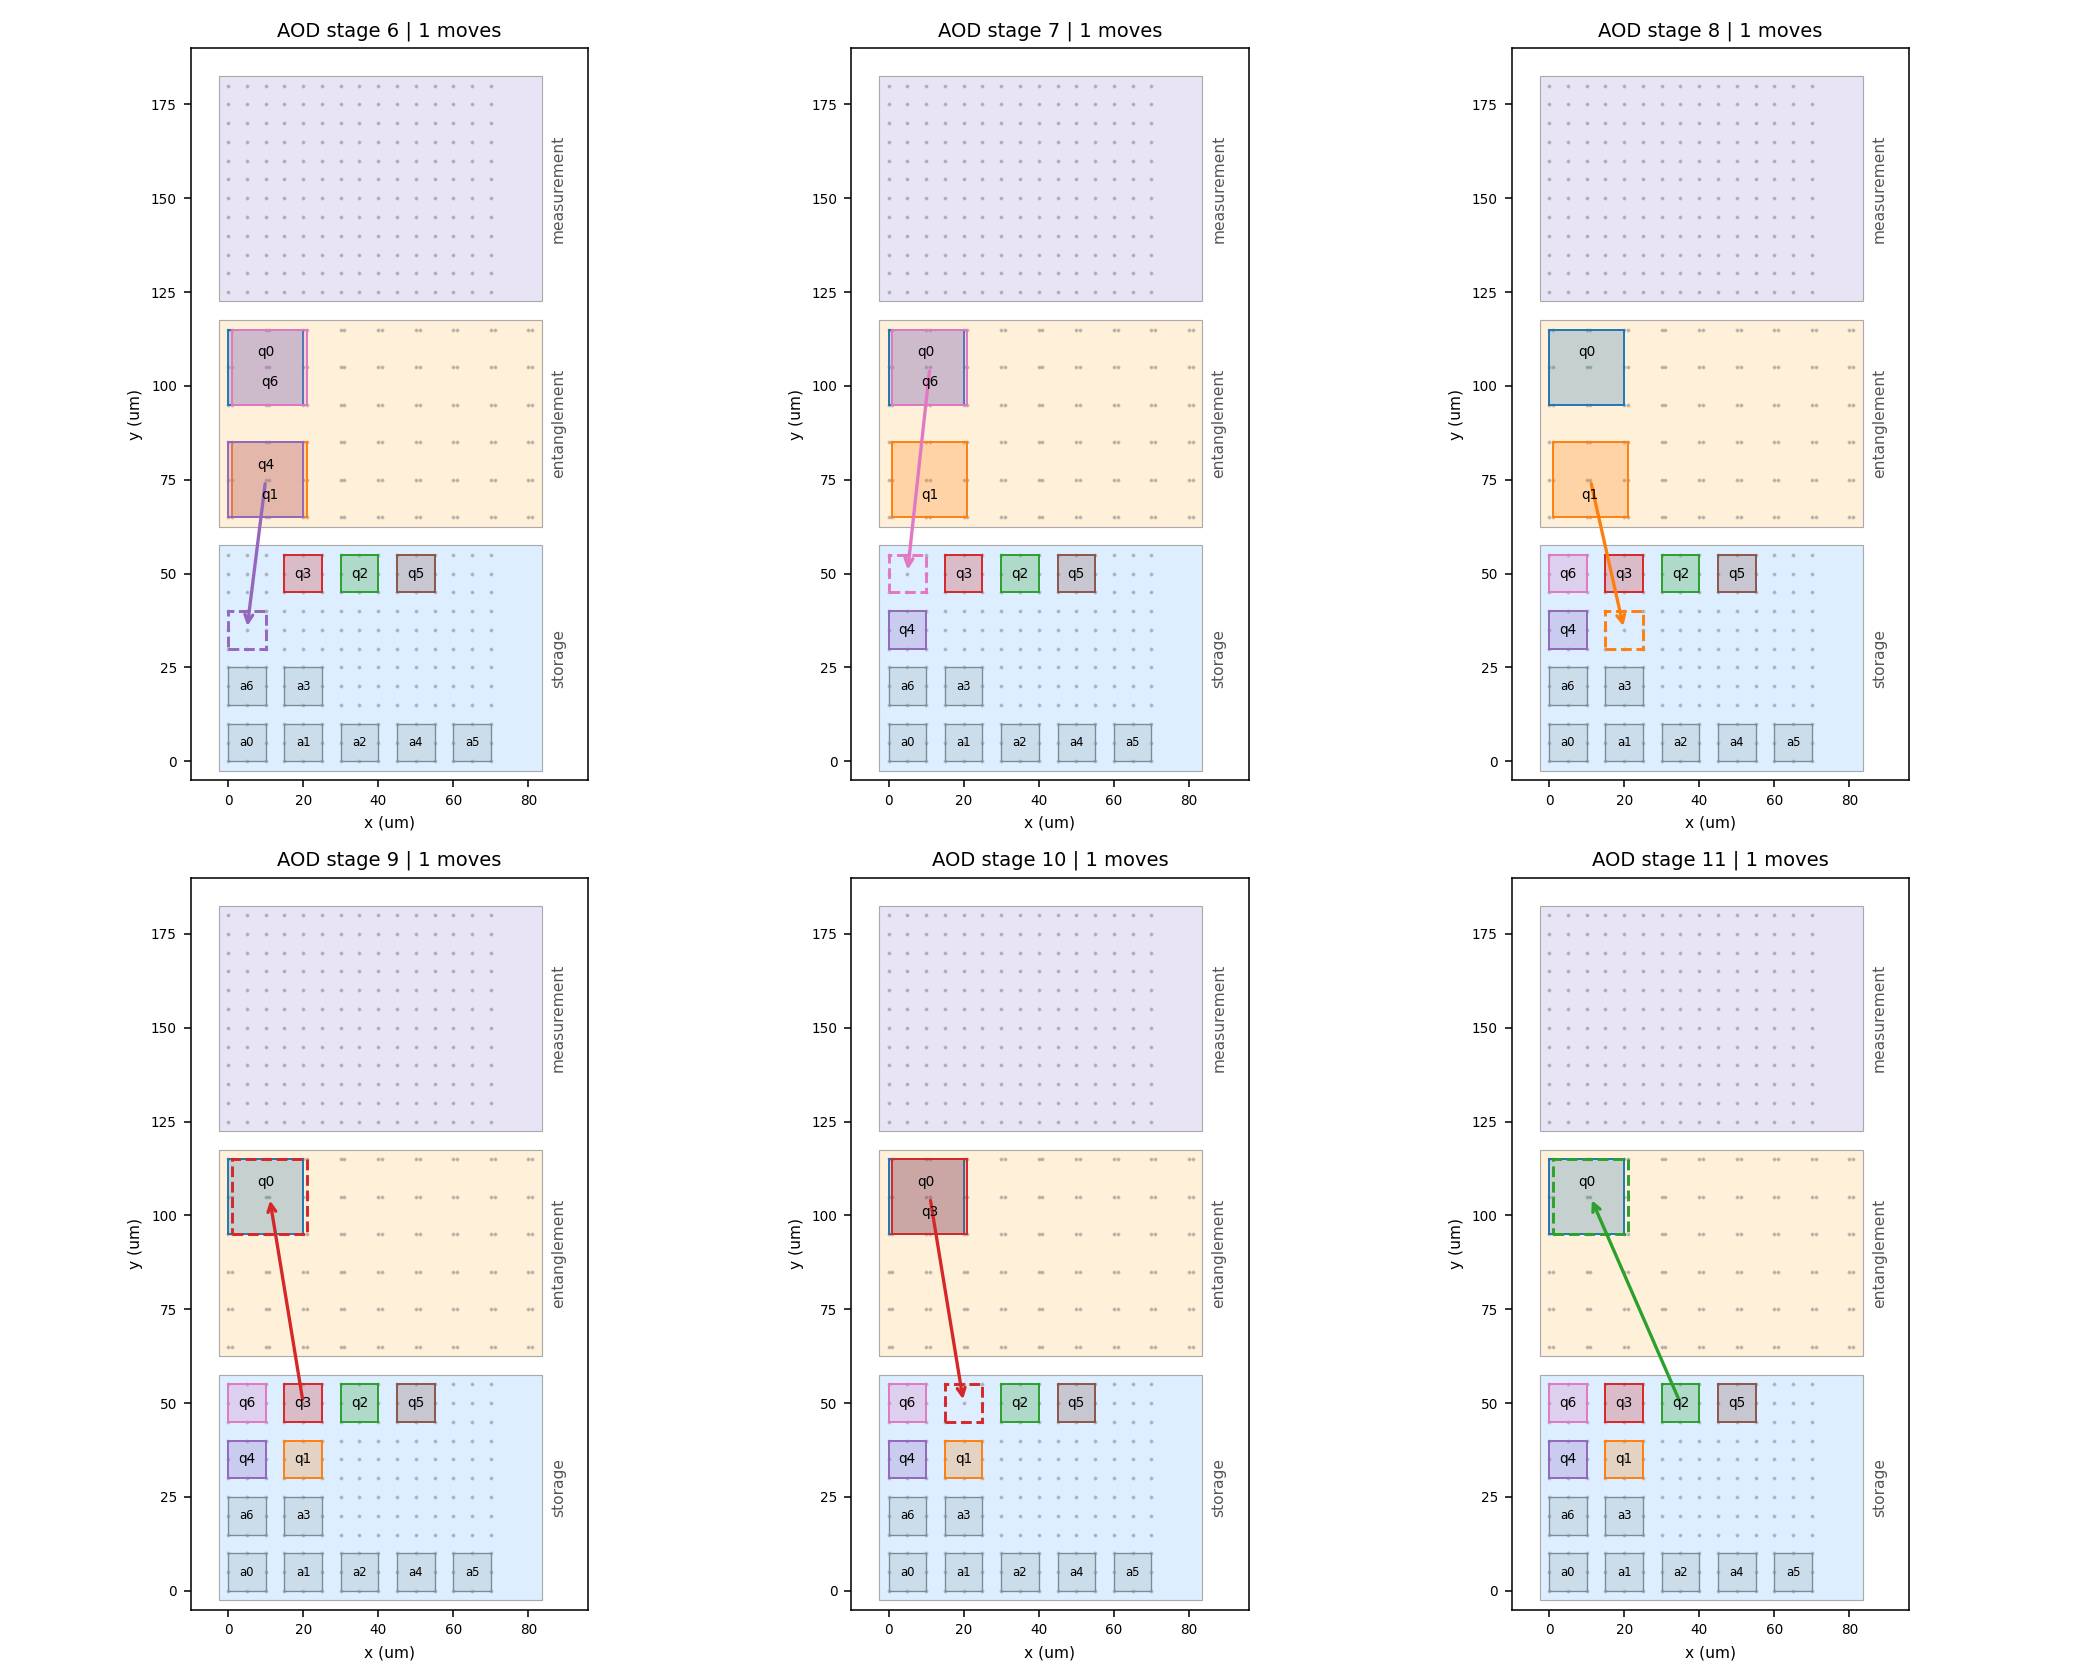

overview_03.png


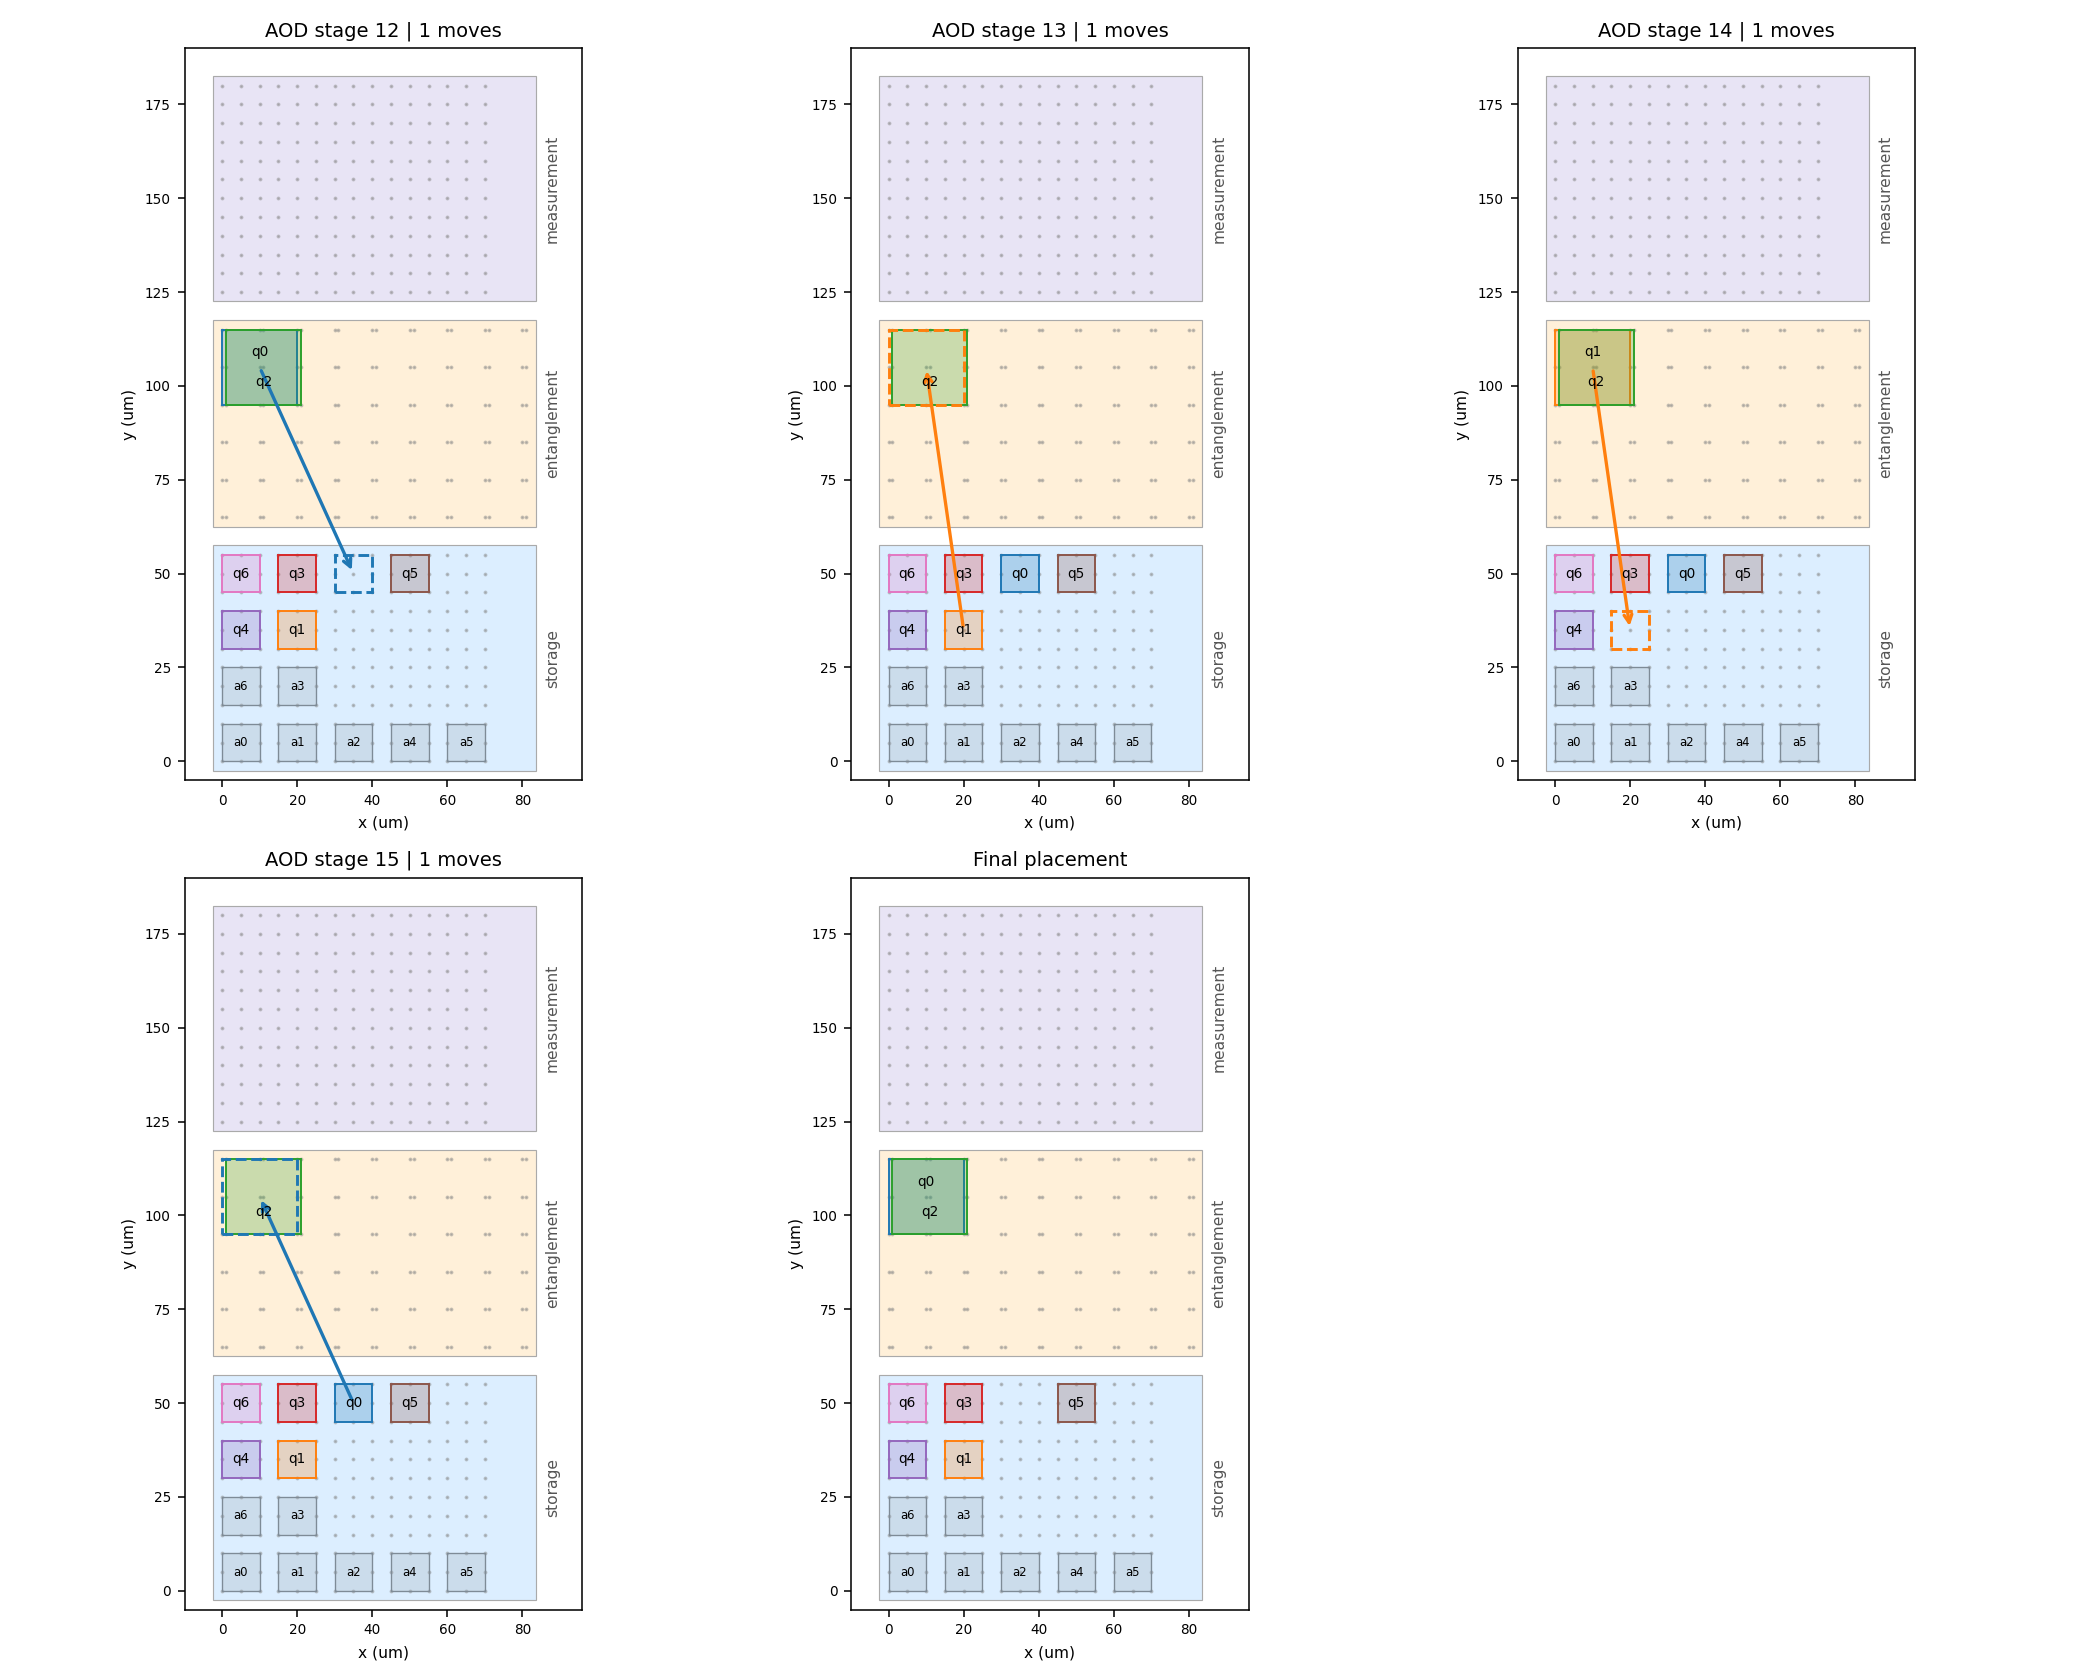

最终位置


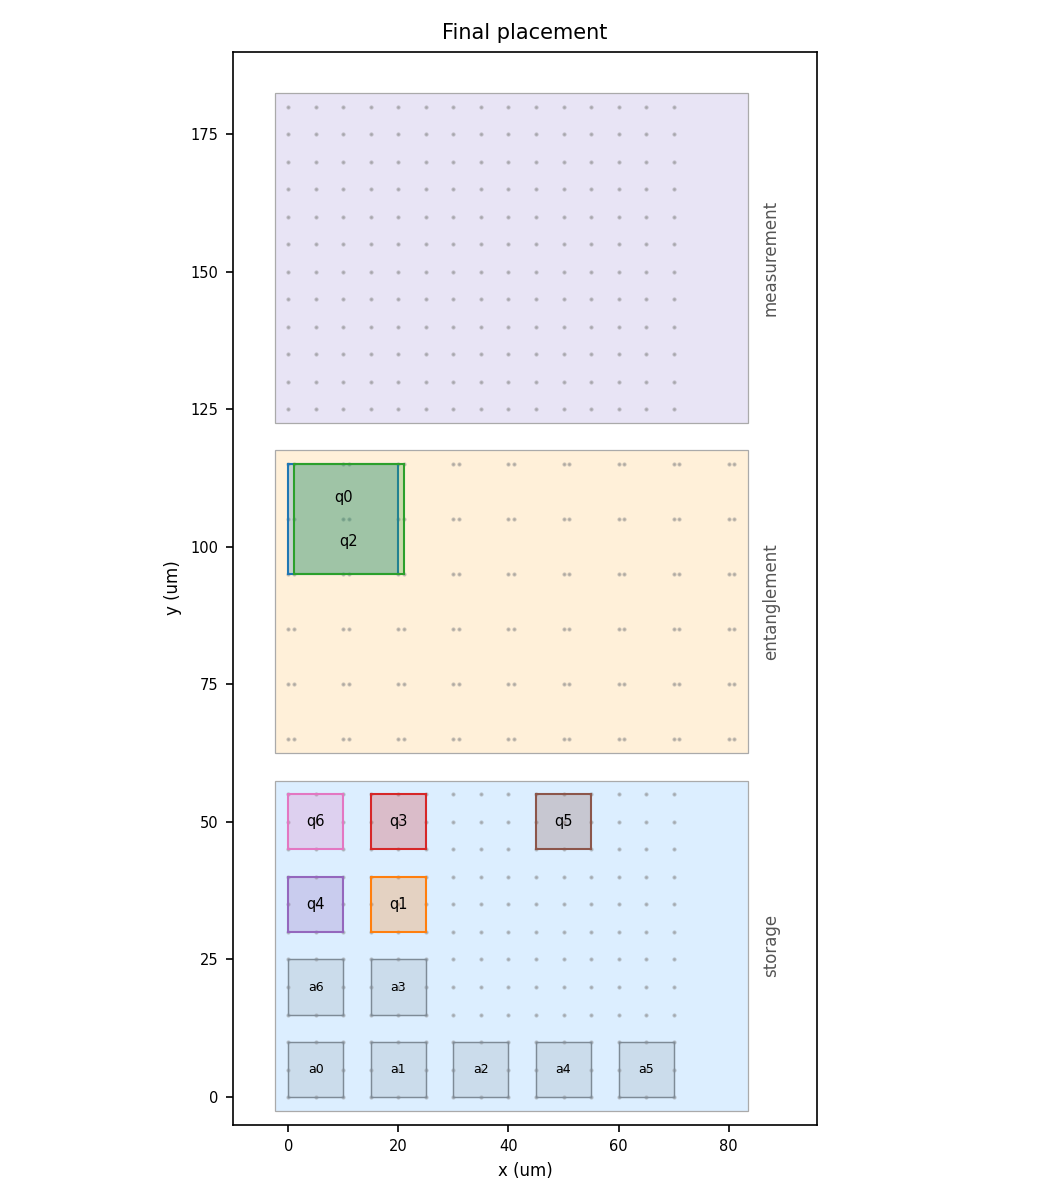

In [9]:
stage_dir = OUT / "stages"
draw_hardware_schedule(processor, schedule, stage_dir)
print("初始布局")
display(Image(filename=str(stage_dir / "initial_mapping.png"), width=650))
for overview in sorted(stage_dir.glob("overview_*.png")):
    print(overview.name)
    display(Image(filename=str(overview), width=1200))
print("最终位置")
display(Image(filename=str(stage_dir / "final_mapping.png"), width=650))


{
  "kind": "aod",
  "nodes": [],
  "moves": [
    {
      "qubit": 6,
      "start": "storage:3:0",
      "target": "entanglement:1:0:1"
    }
  ]
}


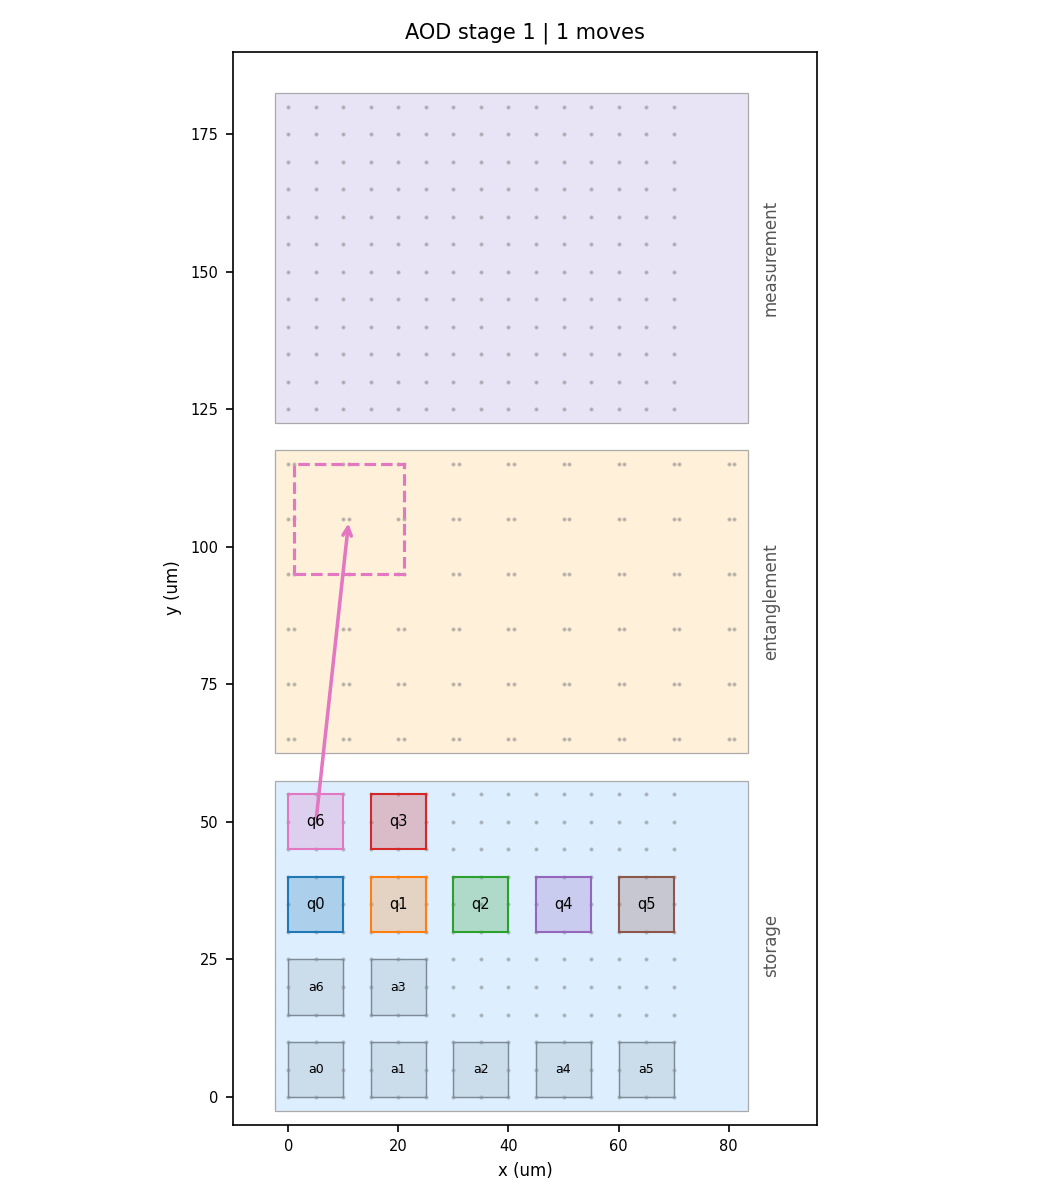

In [10]:
# 修改编号查看任意一张 AOD stage 高清图（1-based）。
stage_index = 1
assert 1 <= stage_index <= schedule.stage_count
aod_blocks = [b for b in schedule.blocks if b.kind == "aod"]
show_json(asdict(aod_blocks[stage_index - 1]))
display(Image(filename=str(stage_dir / f"stage_{stage_index:03d}.png"), width=850))


## 9. 输出索引与当前边界

- `input.qasm` / `clifford.qasm`：输入与静态转换结果。
- `g1.json` / `g2.json`：预处理 IR。
- `compilation.json`：可加载的完整编译产物。
- `logical_circuit.png`：插入 deformation 后的线路。
- `stages/`：初始、最终、逐 stage 与概览图片。

所有文件位于 `outputs/notebook_demo`。当前优化统计只考虑 AOD stage 数；内部 deformation、SE 和真实时间轴不在此演示范围内。
